# 👥 Integrantes

| Nome                                  | RM     |
|---------------------------------------|--------|
| Gabriel Alexandre Fukushima Sakura    | 99522  |
| Henrique de Oliveira Gomes            | 566424 |
| Henrique Kolomyes Silveira            | 563467 |
| Lucas Henrique Viana Estevam Sena     | 566246 |
| Matheus Santos de Oliveira            | 561982 |

# Instalando e importando dependencias

Aqui estamos preparando o terreno para utilizar o projeto, instalando as biblitoecas que iremos utilizar, sendo elas: Networkx, matplotlib e o folium

In [32]:
!pip install -U "networkx>=3.2" "matplotlib>=3.8" "folium>=0.15"


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Agora estamos importanto as bibliotecas que usaremos sendo elas:

- Bibliotecas Nativas: time e tracemalloc para medir a performance (tempo e memória) do algoritmo. Functools para habilitar a técnica de "memoização" (cache). O typing garante que os dados sigam um formato rígido (TypedDict), evitando erros estruturais.

- Bibliotecas de terceiros: networkx (o motor matemático para cálculos de grafos), matplotlib (para desenhos abstratos e diagramas) e folium (para a renderização do mapa geográfico real).

In [33]:
from __future__ import annotations
import pandas as pd
import functools
import sys
import time
import tracemalloc
from pathlib import Path
from typing import TypedDict
import folium
import matplotlib.pyplot as plt
import networkx as nx
from IPython.display import display

if hasattr(sys.stdout, "reconfigure"):
    try:
        sys.stdout.reconfigure(encoding="utf-8")
    except Exception:
        pass

# Estrutura de dados

- O Grafo (PEQUIM_GRAFO,BART_GRAFO,SP_GRAFO:): Ensina ao algoritmo as rotas. Ele usa um dicionário onde cada chave é uma estação, e o valor é uma lista de tuplas contendo os vizinhos diretos e o tempo médio (peso) para chegar até eles.

- As Coordenadas (PEQUIM_COORDS,BART_COORDS,SP_COORDS): Fornece a latitude e a longitude reais de cada estação, permitindo que o Folium saiba exatamente onde colocar o "pino" no mapa interativo.

- As redes (Pequim, Bart, são paulo) que faz as identificações do codigo, separando por cada ID,Area,Local de partida/saida,notas, junta grafos e cordenadas. texto em itálico

In [34]:
class RedeMetro(TypedDict):
    id: str
    titulo: str
    grafo: dict[str, list[tuple[str, float]]]
    coords: dict[str, tuple[float, float]]
    origem_demo: str
    destino_demo: str
    notas: str

PEQUIM_GRAFO: dict[str, list[tuple[str, float]]] = {
    "Sihui East": [("Sihui", 2.0)],
    "Sihui": [("Sihui East", 2.0), ("Dawanglu", 2.5)],
    "Dawanglu": [("Sihui", 2.5), ("Guomao", 2.0)],
    "Guomao": [("Dawanglu", 2.0), ("Yong'anli", 2.0), ("Jintaixizhao", 2.0)],
    "Yong'anli": [("Guomao", 2.0), ("Jianguomen", 2.5)],
    "Jianguomen": [("Yong'anli", 2.5), ("Dongdan", 2.0), ("Chaoyangmen", 2.5), ("Beijing Railway Station", 2.0)],
    "Dongdan": [("Jianguomen", 2.0), ("Wangfujing", 1.5)],
    "Wangfujing": [("Dongdan", 1.5), ("Tian'anmen East", 2.0)],
    "Tian'anmen East": [("Wangfujing", 2.0), ("Tian'anmen West", 1.5)],
    "Tian'anmen West": [("Tian'anmen East", 1.5), ("Xidan", 2.0)],
    "Xidan": [("Tian'anmen West", 2.0), ("Fuxingmen", 2.0), ("Lingjing Hutong", 1.5), ("Xuanwumen", 2.0)],
    "Fuxingmen": [("Xidan", 2.0), ("Fuchengmen", 2.5), ("Changchunjie", 2.0)],
    "Chaoyangmen": [("Jianguomen", 2.5), ("Dongzhimen", 3.0)],
    "Dongzhimen": [("Chaoyangmen", 3.0), ("Yonghegong", 2.5)],
    "Yonghegong": [("Dongzhimen", 2.5), ("Guloudajie", 2.5)],
    "Guloudajie": [("Yonghegong", 2.5), ("Jishuitan", 2.0)],
    "Jishuitan": [("Guloudajie", 2.0), ("Xizhimen", 2.5)],
    "Xizhimen": [("Jishuitan", 2.5), ("Chegongzhuang", 2.0), ("Xinjiekou", 1.5)],
    "Chegongzhuang": [("Xizhimen", 2.0), ("Fuchengmen", 2.0)],
    "Fuchengmen": [("Chegongzhuang", 2.0), ("Fuxingmen", 2.5)],
    "Changchunjie": [("Fuxingmen", 2.0), ("Xuanwumen", 2.0)],
    "Xuanwumen": [("Changchunjie", 2.0), ("Qianmen", 2.5), ("Xidan", 2.0)],
    "Qianmen": [("Xuanwumen", 2.5), ("Chongwenmen", 2.0)],
    "Chongwenmen": [("Qianmen", 2.0), ("Beijing Railway Station", 2.5)],
    "Beijing Railway Station": [("Chongwenmen", 2.5), ("Jianguomen", 2.0)],
    "Xinjiekou": [("Xizhimen", 1.5), ("Ping'anli", 2.0)],
    "Ping'anli": [("Xinjiekou", 2.0), ("Xisi", 1.5)],
    "Xisi": [("Ping'anli", 1.5), ("Lingjing Hutong", 1.5)],
    "Lingjing Hutong": [("Xisi", 1.5), ("Xidan", 1.5)],
    "Jintaixizhao": [("Guomao", 2.0), ("Hujialou", 1.5)],
    "Hujialou": [("Jintaixizhao", 1.5), ("Tuanjiehu", 2.0)],
    "Tuanjiehu": [("Hujialou", 2.0), ("Agricultural Exhibition Center", 2.0)],
    "Agricultural Exhibition Center": [("Tuanjiehu", 2.0)],
}

PEQUIM_COORDS: dict[str, tuple[float, float]] = {
    "Sihui East": (39.9085, 116.5155),
    "Sihui": (39.9077, 116.4965),
    "Dawanglu": (39.9080, 116.4770),
    "Guomao": (39.9090, 116.4600),
    "Yong'anli": (39.9088, 116.4500),
    "Jianguomen": (39.9087, 116.4355),
    "Dongdan": (39.9085, 116.4175),
    "Wangfujing": (39.9083, 116.4100),
    "Tian'anmen East": (39.9082, 116.3980),
    "Tian'anmen West": (39.9080, 116.3900),
    "Xidan": (39.9078, 116.3740),
    "Fuxingmen": (39.9075, 116.3520),
    "Chaoyangmen": (39.9240, 116.4330),
    "Dongzhimen": (39.9410, 116.4330),
    "Yonghegong": (39.9480, 116.4170),
    "Guloudajie": (39.9480, 116.3940),
    "Jishuitan": (39.9480, 116.3720),
    "Xizhimen": (39.9402, 116.3555),
    "Chegongzhuang": (39.9325, 116.3540),
    "Fuchengmen": (39.9230, 116.3530),
    "Changchunjie": (39.8990, 116.3520),
    "Xuanwumen": (39.8990, 116.3740),
    "Qianmen": (39.8990, 116.3980),
    "Chongwenmen": (39.8990, 116.4170),
    "Beijing Railway Station": (39.9030, 116.4250),
    "Xinjiekou": (39.9400, 116.3650),
    "Ping'anli": (39.9332, 116.3720),
    "Xisi": (39.9240, 116.3730),
    "Lingjing Hutong": (39.9160, 116.3735),
    "Jintaixizhao": (39.9155, 116.4600),
    "Hujialou": (39.9230, 116.4605),
    "Tuanjiehu": (39.9335, 116.4610),
    "Agricultural Exhibition Center": (39.9420, 116.4615),
}

BART_GRAFO: dict[str, list[tuple[str, float]]] = {
    "Dublin/Pleasanton": [("West Dublin", 3.0)],
    "West Dublin": [("Dublin/Pleasanton", 3.0), ("Castro Valley", 3.0)],
    "Castro Valley": [("West Dublin", 3.0), ("Hayward", 3.0)],
    "Hayward": [("Castro Valley", 3.0), ("South Hayward", 3.0), ("Bay Fair", 3.0)],
    "South Hayward": [("Hayward", 3.0), ("Union City", 3.0)],
    "Union City": [("South Hayward", 3.0), ("Fremont", 3.0)],
    "Fremont": [("Union City", 3.0), ("Warm Springs", 3.0)],
    "Warm Springs": [("Fremont", 3.0), ("Milpitas", 3.0)],
    "Milpitas": [("Warm Springs", 3.0), ("Berryessa", 3.0)],
    "Berryessa": [("Milpitas", 3.0)],
    "Bay Fair": [("Hayward", 3.0), ("San Leandro", 3.0)],
    "San Leandro": [("Bay Fair", 3.0), ("Coliseum", 3.0)],
    "Coliseum": [("San Leandro", 3.0), ("Fruitvale", 2.5), ("Oakland Airport", 4.0)],
    "Oakland Airport": [("Coliseum", 4.0)],
    "Fruitvale": [("Coliseum", 2.5), ("Lake Merritt", 2.5)],
    "Lake Merritt": [("Fruitvale", 2.5), ("12th St Oakland", 2.5)],
    "12th St Oakland": [("Lake Merritt", 2.5), ("19th St Oakland", 2.0)],
    "19th St Oakland": [("12th St Oakland", 2.0), ("MacArthur", 2.5)],
    "MacArthur": [("19th St Oakland", 2.5), ("West Oakland", 2.5), ("Rockridge", 3.0)],
    "Rockridge": [("MacArthur", 3.0), ("Orinda", 4.0)],
    "Orinda": [("Rockridge", 4.0)],
    "West Oakland": [("MacArthur", 2.5), ("Embarcadero", 3.5)],
    "Embarcadero": [("West Oakland", 3.5), ("Montgomery", 1.5)],
    "Montgomery": [("Embarcadero", 1.5), ("Powell", 1.2), ("SFO Airport", 12.0)],
    "Powell": [("Montgomery", 1.2), ("Civic Center", 1.2)],
    "Civic Center": [("Powell", 1.2), ("16th St Mission", 1.5)],
    "16th St Mission": [("Civic Center", 1.5), ("24th St Mission", 1.5)],
    "24th St Mission": [("16th St Mission", 1.5), ("Glen Park", 2.0)],
    "Glen Park": [("24th St Mission", 2.0), ("Balboa Park", 2.0)],
    "Balboa Park": [("Glen Park", 2.0), ("Daly City", 2.5)],
    "Daly City": [("Balboa Park", 2.5), ("Millbrae", 4.0)],
    "SFO Airport": [("Montgomery", 12.0), ("Millbrae", 6.0)],
    "Millbrae": [("Daly City", 4.0), ("SFO Airport", 6.0)],
}

BART_COORDS: dict[str, tuple[float, float]] = {
    "Dublin/Pleasanton": (37.7017, -121.8992),
    "West Dublin": (37.6997, -121.9280),
    "Castro Valley": (37.6907, -122.0758),
    "Hayward": (37.6693, -122.0870),
    "South Hayward": (37.6344, -122.0570),
    "Union City": (37.5902, -122.0170),
    "Fremont": (37.5574, -121.9764),
    "Warm Springs": (37.5022, -121.9394),
    "Milpitas": (37.4103, -121.8910),
    "Berryessa": (37.3686, -121.8747),
    "Bay Fair": (37.6969, -122.1264),
    "San Leandro": (37.7219, -122.1608),
    "Coliseum": (37.7537, -122.1974),
    "Oakland Airport": (37.7131, -122.2122),
    "Fruitvale": (37.7748, -122.2242),
    "Lake Merritt": (37.7975, -122.2654),
    "12th St Oakland": (37.8037, -122.2716),
    "19th St Oakland": (37.8077, -122.2688),
    "MacArthur": (37.8292, -122.2670),
    "Rockridge": (37.8442, -122.2512),
    "Orinda": (37.8824, -122.1838),
    "West Oakland": (37.8049, -122.2951),
    "Embarcadero": (37.7931, -122.3964),
    "Montgomery": (37.7894, -122.4014),
    "Powell": (37.7844, -122.4079),
    "Civic Center": (37.7795, -122.4136),
    "16th St Mission": (37.7651, -122.4196),
    "24th St Mission": (37.7523, -122.4184),
    "Glen Park": (37.7331, -122.4338),
    "Balboa Park": (37.7216, -122.4475),
    "Daly City": (37.7061, -122.4690),
    "SFO Airport": (37.6163, -122.3910),
    "Millbrae": (37.5998, -122.3867),
}

SP_GRAFO: dict[str, list[tuple[str, float]]] = {
    "Tucuruvi": [("Parada Inglesa", 3.0)],
    "Parada Inglesa": [("Tucuruvi", 3.0), ("Jardim São Paulo", 3.0)],
    "Jardim São Paulo": [("Parada Inglesa", 3.0), ("Santana", 3.0)],
    "Santana": [("Jardim São Paulo", 3.0), ("Carandiru", 2.5)],
    "Carandiru": [("Santana", 2.5), ("Portuguesa-Tietê", 2.5)],
    "Portuguesa-Tietê": [("Carandiru", 2.5), ("Armênia", 2.5)],
    "Armênia": [("Portuguesa-Tietê", 2.5), ("Tiradentes", 2.5)],
    "Tiradentes": [("Armênia", 2.5), ("Luz", 2.5)],
    "Luz": [("Tiradentes", 2.5), ("São Bento", 2.0), ("Brás CPTM", 3.0)],
    "Brás CPTM": [("Luz", 3.0)],
    "São Bento": [("Luz", 2.0), ("Sé", 2.0)],
    "Sé": [("São Bento", 2.0), ("Paraíso", 3.0)],
    "Paraíso": [("Sé", 3.0), ("Vergueiro", 2.0)],
    "Vergueiro": [("Paraíso", 2.0), ("São Joaquim", 2.0)],
    "São Joaquim": [("Vergueiro", 2.0), ("Saúde", 2.0)],
    "Saúde": [("São Joaquim", 2.0), ("São Judas", 2.0)],
    "São Judas": [("Saúde", 2.0), ("Hospital São Paulo", 2.0)],
    "Hospital São Paulo": [("São Judas", 2.0), ("Giovanni Gronchi", 3.0)],
    "Giovanni Gronchi": [("Hospital São Paulo", 3.0), ("Santo Amaro", 3.0)],
    "Santo Amaro": [("Giovanni Gronchi", 3.0), ("Largo Treze", 3.0)],
    "Largo Treze": [("Santo Amaro", 3.0), ("Adolfo Pinheiro", 3.0)],
    "Adolfo Pinheiro": [("Largo Treze", 3.0), ("Pedreira", 2.5)],
    "Pedreira": [("Adolfo Pinheiro", 2.5), ("Capão Redondo", 3.0)],
    "Capão Redondo": [("Pedreira", 3.0)],
}

SP_COORDS: dict[str, tuple[float, float]] = {
    "Tucuruvi": (-23.4796, -46.6038),
    "Parada Inglesa": (-23.4827, -46.6085),
    "Jardim São Paulo": (-23.4894, -46.6184),
    "Santana": (-23.4940, -46.6250),
    "Carandiru": (-23.5010, -46.6250),
    "Portuguesa-Tietê": (-23.5080, -46.6250),
    "Armênia": (-23.5150, -46.6260),
    "Tiradentes": (-23.5250, -46.6280),
    "Luz": (-23.5360, -46.6335),
    "Brás CPTM": (-23.5440, -46.6060),
    "São Bento": (-23.5440, -46.6340),
    "Sé": (-23.5500, -46.6330),
    "Paraíso": (-23.5750, -46.6405),
    "Vergueiro": (-23.5800, -46.6420),
    "São Joaquim": (-23.5860, -46.6435),
    "Saúde": (-23.5930, -46.6450),
    "São Judas": (-23.6000, -46.6465),
    "Hospital São Paulo": (-23.6065, -46.6420),
    "Giovanni Gronchi": (-23.6120, -46.6400),
    "Santo Amaro": (-23.6180, -46.6380),
    "Largo Treze": (-23.6250, -46.6360),
    "Adolfo Pinheiro": (-23.6320, -46.6340),
    "Pedreira": (-23.6400, -46.6320),
    "Capão Redondo": (-23.6480, -46.6280),
}

REDES: dict[str, RedeMetro] = {
    "pequim": {
        "id": "pequim",
        "titulo": "Pequim (L1, L2, L4, L10)",
        "grafo": PEQUIM_GRAFO,
        "coords": PEQUIM_COORDS,
        "origem_demo": "Sihui East",
        "destino_demo": "Xizhimen",
        "notas": "Grafo estendido com o loop completo da L2, cruzamentos centrais da L1 e L4.",
    },
    "bart": {
        "id": "bart",
        "titulo": "BART (Bay Area)",
        "grafo": BART_GRAFO,
        "coords": BART_COORDS,
        "origem_demo": "Dublin/Pleasanton",
        "destino_demo": "Daly City",
        "notas": "Ramo leste verde, ramo norte amarelo, tronco SF e ramos SFO/Millbrae.",
    },
    "sao_paulo": {
        "id": "sao_paulo",
        "titulo": "Metrô + CPTM (São Paulo)",
        "grafo": SP_GRAFO,
        "coords": SP_COORDS,
        "origem_demo": "Tucuruvi",
        "destino_demo": "Capão Redondo",
        "notas": "Integração Luz (CPTM) e Hospital São Paulo (L1/L5).",
    },
}

# Local de motor de logica e busca dos caminhos

- fator_horario: Simula a vida real aplicando multiplicadores de tempo. Exemplo: se for 18h (pico), o tempo da viagem dobra (fator 2.0).

- menor_custo: Uma função recursiva poderosa que descobre o caminho mais rápido. Ela usa @functools.lru_cache para "lembrar" cálculos antigos, economizando muita memória e processamento.

- grafo_networkx: Um "tradutor" que pega o nosso dicionário manual e o transforma num objeto formal da biblioteca NetworkX, liberando acesso a algoritmos complexos de menor caminho (como o algoritmo de Dijkstra).

- sugestoes_todas_pares: Gera sugestões de rotas entre todas as combinações possíveis de estações. Para cada par, calcula o custo com a função recursiva e também o caminho usando o NetworkX.

- caminhos_simples_distintos: Encontra vários caminhos diferentes entre duas estações (sem repetir nós). Usa uma função pronta do NetworkX para listar caminhos possíveis, limitado por um número máximo.

- limpar_cache_menor_custo: Limpa a memória da função com memoização. Isso é importante para testes e medições de desempenho, garantindo que o cálculo comece “do zero”.

In [35]:
def fator_horario(hora: int) -> float:
    if 5 <= hora < 7:
        return 0.6
    if 7 <= hora < 9:
        return 1.5
    if 9 <= hora < 17:
        return 1.0
    if 17 <= hora < 20:
        return 2.0
    return 1.0

@functools.lru_cache(maxsize=None)
def menor_custo(rede_id: str, origem: str, destino: str, horario: int, visitados: frozenset[str]) -> float:
    grafo = REDES[rede_id]["grafo"]
    if origem == destino:
        return 0.0
    if origem not in grafo:
        return float("inf")
    fator = fator_horario(horario)
    melhor = float("inf")
    for vizinho, peso in grafo[origem]:
        if vizinho not in visitados:
            custo = fator * peso + menor_custo(rede_id, vizinho, destino, horario, visitados | {origem})
            melhor = min(melhor, custo)
    return melhor

def grafo_networkx(grafo: dict[str, list[tuple[str, float]]]) -> nx.Graph:
    G = nx.Graph()
    for u, vizinhos in grafo.items():
        for v, w in vizinhos:
            G.add_edge(u, v, weight=w, minutes=w)
    return G

def sugestoes_todas_pares(rede_id: str, horario: int) -> list[tuple[str, str, float, list[str]]]:
    grafo = REDES[rede_id]["grafo"]
    estacoes = list(grafo.keys())
    G = grafo_networkx(grafo)
    out: list[tuple[str, str, float, list[str]]] = []
    for o in estacoes:
        for d in estacoes:
            if o == d:
                continue
            custo = menor_custo(rede_id, o, d, horario, frozenset())
            if nx.has_path(G, o, d):
                caminho = nx.shortest_path(G, o, d, weight="weight")
            else:
                caminho = []
            out.append((o, d, custo, caminho))
    return out

def caminhos_simples_distintos(G: nx.Graph, origem: str, destino: str, max_caminhos: int = 8) -> list[list[str]]:
    try:
        gen = nx.all_simple_paths(G, origem, destino, cutoff=len(G) + 1)
        return [p for _, p in zip(range(max_caminhos), gen)]
    except nx.NodeNotFound:
        return []

def limpar_cache_menor_custo() -> None:
    menor_custo.cache_clear()

# Obtenção dos resultados matematicos e sua transformação em imagens faceis de se entender e ler

- plot_matplotlib_rede: Desenha um diagrama topológico. Ele espalha as estações de forma organizada na tela. Se uma rota ideal for fornecida, ele pinta essa rota de vermelho e deixa o resto cinza, destacando o percurso.

In [36]:
def plot_matplotlib_rede(rede_id: str, caminho_destaque: list[str] | None = None) -> None:
    r = REDES[rede_id]
    G = grafo_networkx(r["grafo"])
    pos = nx.spring_layout(G, seed=42, k=2.0 / max(1, len(G) ** 0.5))
    plt.figure(figsize=(12, 8))
    nx.draw_networkx_nodes(G, pos, node_color="#1a5276", node_size=900)
    nx.draw_networkx_labels(G, pos, font_size=7, font_color="white")
    arestas = list(G.edges())
    cores: list[str] = []
    larguras: list[float] = []

    if caminho_destaque and len(caminho_destaque) >= 2:
        pares = set(zip(caminho_destaque[:-1], caminho_destaque[1:]))
        pares |= {(b, a) for (a, b) in pares}
        for u, v in arestas:
            if (u, v) in pares or (v, u) in pares:
                cores.append("#e74c3c")
                larguras.append(3.0)
            else:
                cores.append("#bdc3c7")
                larguras.append(1.2)
    else:
        cores = ["#3498db"] * len(arestas)
        larguras = [1.5] * len(arestas)

    nx.draw_networkx_edges(G, pos, edgelist=arestas, edge_color=cores, width=larguras)
    labels = {(u, v): f"{d['weight']:.0f}" for u, v, d in G.edges(data=True)}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=labels, font_size=6)
    plt.title(r["titulo"])
    plt.axis("off")
    plt.tight_layout()

    nome = f"metro_grafo_{rede_id}.png"
    out = Path.cwd() / nome
    plt.savefig(out, dpi=120)
    plt.show()

- mapa_folium_rede: Uma função de renderização geográfica inteligente. Ela usa a base real de ruas (CartoDB), plota as estações com base em GPS e, usando dicionários de cores e linhas, pinta o trajeto dinamicamente (ex: Azul na Linha 1, Lilás na Linha 5) para espelhar perfeitamente o mapa do metrô da vida real.

In [37]:
def mapa_folium_rede(rede_id: str, caminho: list[str], arquivo: str | None = None) -> folium.Map | None:
    r = REDES[rede_id]
    coords = r["coords"]
    if not caminho:
        return None

    #as cores das linhas são as cores oficiais de cada linha de estação do pais escolhido
    CORES = {
        "pequim": {
            "L1": "#E5001F", "L2": "#004B87", "L4": "#008E9C", "L10": "#0092C7"
        },
        "bart": {
            "Blue": "#00AEEF", "Green": "#4DB848", "Yellow": "#FFE800", "Red": "#ED1C24", "OAK": "#A1A1A4"
        },
        "sao_paulo": {
            "L1": "#00539F", "L5": "#A54499", "CPTM": "#ED1C24"
        }
    }

    LINHAS = {
        "pequim": {
            "L1": {"Sihui East", "Sihui", "Dawanglu", "Guomao", "Yong'anli", "Jianguomen", "Dongdan", "Wangfujing", "Tian'anmen East", "Tian'anmen West", "Xidan", "Fuxingmen"},
            "L2": {"Chaoyangmen", "Dongzhimen", "Yonghegong", "Guloudajie", "Jishuitan", "Xizhimen", "Chegongzhuang", "Fuchengmen", "Fuxingmen", "Changchunjie", "Xuanwumen", "Qianmen", "Chongwenmen", "Beijing Railway Station", "Jianguomen"},
            "L4": {"Xizhimen", "Xinjiekou", "Ping'anli", "Xisi", "Lingjing Hutong", "Xidan", "Xuanwumen"},
            "L10": {"Guomao", "Jintaixizhao", "Hujialou", "Tuanjiehu", "Agricultural Exhibition Center"}
        },
        "bart": {
            "Blue": {"Dublin/Pleasanton", "West Dublin", "Castro Valley", "Bay Fair", "San Leandro", "Coliseum", "Fruitvale", "Lake Merritt", "West Oakland", "Embarcadero", "Montgomery", "Powell", "Civic Center", "16th St Mission", "24th St Mission", "Glen Park", "Balboa Park", "Daly City"},
            "Green": {"Berryessa", "Milpitas", "Warm Springs", "Fremont", "Union City", "South Hayward", "Hayward", "Bay Fair", "San Leandro", "Coliseum", "Fruitvale", "Lake Merritt", "West Oakland", "Embarcadero", "Montgomery", "Powell", "Civic Center", "16th St Mission", "24th St Mission", "Glen Park", "Balboa Park", "Daly City"},
            "Yellow": {"Orinda", "Rockridge", "MacArthur", "19th St Oakland", "12th St Oakland", "West Oakland", "Embarcadero", "Montgomery", "Powell", "Civic Center", "16th St Mission", "24th St Mission", "Glen Park", "Balboa Park", "Daly City", "SFO Airport", "Millbrae"},
            "OAK": {"Oakland Airport", "Coliseum"}
        },
        "sao_paulo": {
            "L1": {"Tucuruvi", "Parada Inglesa", "Jardim São Paulo", "Santana", "Carandiru", "Portuguesa-Tietê", "Armênia", "Tiradentes", "Luz", "São Bento", "Sé", "Paraíso", "Vergueiro", "São Joaquim", "Saúde", "São Judas", "Hospital São Paulo"},
            "L5": {"Hospital São Paulo", "Giovanni Gronchi", "Santo Amaro", "Largo Treze", "Adolfo Pinheiro", "Pedreira", "Capão Redondo"},
            "CPTM": {"Luz", "Brás CPTM"}
        }
    }

    def descobrir_cor_trecho(estacao_a: str, estacao_b: str) -> str:
        if rede_id not in LINHAS:
            return "#c0392b"
        mapa_linhas_atual = LINHAS[rede_id]
        mapa_cores_atual = CORES[rede_id]
        for linha, estacoes in mapa_linhas_atual.items():
            if estacao_a in estacoes and estacao_b in estacoes:
                return mapa_cores_atual[linha]
        return "#34495e"

    lats = [coords[s][0] for s in caminho if s in coords]
    lons = [coords[s][1] for s in caminho if s in coords]

    if not lats:
        return None

    centro = (sum(lats) / len(lats), sum(lons) / len(lons))
    m = folium.Map(location=centro, zoom_start=12, tiles="CartoDB positron")

    for i in range(len(caminho) - 1):
        u, v = caminho[i], caminho[i+1]
        if u in coords and v in coords:
            cor_trecho = descobrir_cor_trecho(u, v)
            folium.PolyLine(
                locations=[coords[u], coords[v]],
                color=cor_trecho,
                weight=6,
                opacity=0.9,
                tooltip=f"Trecho: {u} → {v}"
            ).add_to(m)

    for nome in caminho:
        if nome in coords:
            lat, lon = coords[nome]
            folium.CircleMarker(
                location=[lat, lon],
                radius=6,
                popup=nome,
                tooltip=nome,
                color="#2c3e50",
                fill=True,
                fill_color="#ffffff",
                fill_opacity=1
            ).add_to(m)

    nome_arq = arquivo or f"metro_mapa_{rede_id}.html"
    path = Path.cwd() / nome_arq
    m.save(str(path))

    return m

# Geração de relatórios no console para auditoria dos dados

Cada função (uma para cada cidade) calcula o trajeto usando NetworkX e imprime no console as informações vitais: número de paradas, as estações exatas por onde passar, se existem pontos de bifurcação (grau >= 3) e o custo total em minutos considerando o horário de pico simulado.

In [38]:
def relatorio_pequim(horario: int) -> None:
    r = REDES["pequim"]
    G = grafo_networkx(r["grafo"])
    o, d = r["origem_demo"], r["destino_demo"]
    sp = nx.shortest_path(G, o, d, weight="weight")
    n_arestas = len(sp) - 1
    todos = caminhos_simples_distintos(G, o, d, max_caminhos=20)
    print(f"\n=== {r['titulo']} ===")
    print(r["notas"])
    print(f"Menor caminho {o} → {d}: {n_arestas} trechos | {' → '.join(sp)}")
    print(f"Caminhos simples distintos (amostra): {len(todos)}")
    for i, p in enumerate(todos[:5], 1):
        print(f"  {i}. ({len(p) - 1} trechos) {' → '.join(p)}")
    print(f"Custo memoizado (horário {horario}): {menor_custo('pequim', o, d, horario, frozenset()):.2f}")

def relatorio_bart(horario: int) -> None:
    r = REDES["bart"]
    G = grafo_networkx(r["grafo"])
    o, d = r["origem_demo"], r["destino_demo"]
    sp = nx.shortest_path(G, o, d, weight="weight")
    print(f"\n=== {r['titulo']} ===")
    print(r["notas"])
    print(f"Menor caminho {o} → {d}: {' → '.join(sp)}")
    hubs = [n for n in G.nodes if G.degree(n) >= 3]
    print(f"Estações com bifurcação (grau ≥ 3): {', '.join(sorted(hubs))}")
    print(f"Custo memoizado: {menor_custo('bart', o, d, horario, frozenset()):.2f}")

def relatorio_sao_paulo(horario: int) -> None:
    r = REDES["sao_paulo"]
    G = grafo_networkx(r["grafo"])
    o, d = r["origem_demo"], r["destino_demo"]
    sp = nx.shortest_path(G, o, d, weight="weight")
    integracoes = {"Luz", "Hospital São Paulo"}
    passa = [s for s in sp if s in integracoes]
    print(f"\n=== {r['titulo']} ===")
    print(r["notas"])
    print(f"Menor caminho {o} → {d}: {' → '.join(sp)}")
    print(f"Estações de integração no percurso: {', '.join(passa) if passa else '(nenhuma)'}")
    print(f"Custo memoizado: {menor_custo('sao_paulo', o, d, horario, frozenset()):.2f}")

# Interação com o usuario para colocar o horario

In [39]:
entrada = input("Digite o horário de partida (0 a 23): ")

try:
    horario_atual = int(entrada)
    if not (0 <= horario_atual <= 23):
        print("Horário inválido! Usando o horário de pico padrão: 18h.")
        horario_atual = 18
except ValueError:
    print("Entrada inválida (não é um número inteiro). Usando horário padrão: 18h.")
    horario_atual = 18

print(f"\n>>> Calculando rotas e tempo de viagem para as {horario_atual}h...\n")


>>> Calculando rotas e tempo de viagem para as 12h...



# Execução de pequim

- Bloco do folium:

In [40]:
horario_atual = 18
limpar_cache_menor_custo()
caminho_pq = nx.shortest_path(
    grafo_networkx(REDES["pequim"]["grafo"]),
    REDES["pequim"]["origem_demo"],
    REDES["pequim"]["destino_demo"],
    weight="weight",
)
mapa_pq = mapa_folium_rede("pequim", caminho_pq)
display(mapa_pq)

- Chamando a função do matplotlib:

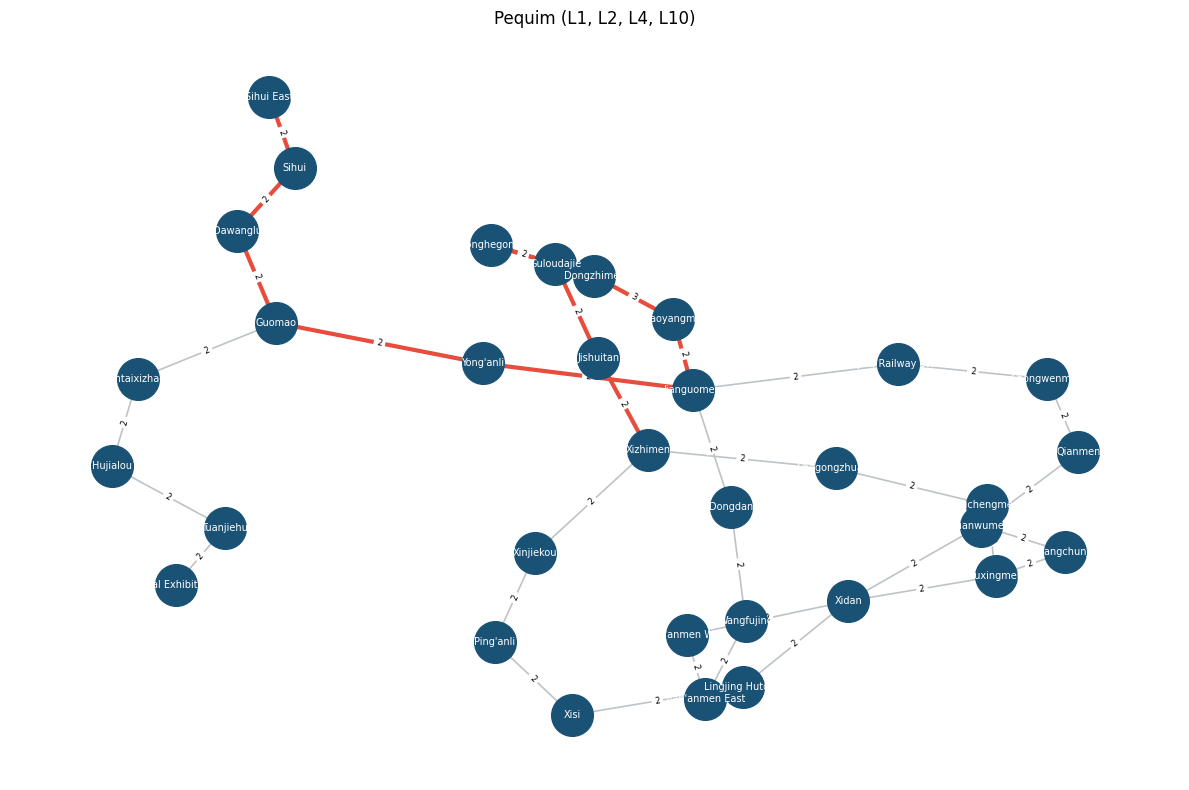

In [41]:
plot_matplotlib_rede("pequim", caminho_destaque=caminho_pq)

- Bloco do relatório:

In [42]:
relatorio_pequim(horario_atual)


=== Pequim (L1, L2, L4, L10) ===
Grafo estendido com o loop completo da L2, cruzamentos centrais da L1 e L4.
Menor caminho Sihui East → Xizhimen: 11 trechos | Sihui East → Sihui → Dawanglu → Guomao → Yong'anli → Jianguomen → Chaoyangmen → Dongzhimen → Yonghegong → Guloudajie → Jishuitan → Xizhimen
Caminhos simples distintos (amostra): 8
  1. (14 trechos) Sihui East → Sihui → Dawanglu → Guomao → Yong'anli → Jianguomen → Dongdan → Wangfujing → Tian'anmen East → Tian'anmen West → Xidan → Fuxingmen → Fuchengmen → Chegongzhuang → Xizhimen
  2. (15 trechos) Sihui East → Sihui → Dawanglu → Guomao → Yong'anli → Jianguomen → Dongdan → Wangfujing → Tian'anmen East → Tian'anmen West → Xidan → Lingjing Hutong → Xisi → Ping'anli → Xinjiekou → Xizhimen
  3. (16 trechos) Sihui East → Sihui → Dawanglu → Guomao → Yong'anli → Jianguomen → Dongdan → Wangfujing → Tian'anmen East → Tian'anmen West → Xidan → Xuanwumen → Changchunjie → Fuxingmen → Fuchengmen → Chegongzhuang → Xizhimen
  4. (11 trechos) Sihu

# Execução de bart

- Bloco do folium:

In [43]:
caminho_bart = nx.shortest_path(
    grafo_networkx(REDES["bart"]["grafo"]),
    REDES["bart"]["origem_demo"],
    REDES["bart"]["destino_demo"],
    weight="weight",
)
mapa_b = mapa_folium_rede("bart", caminho_bart)
display(mapa_b)

- Chamando a função matplotlib:

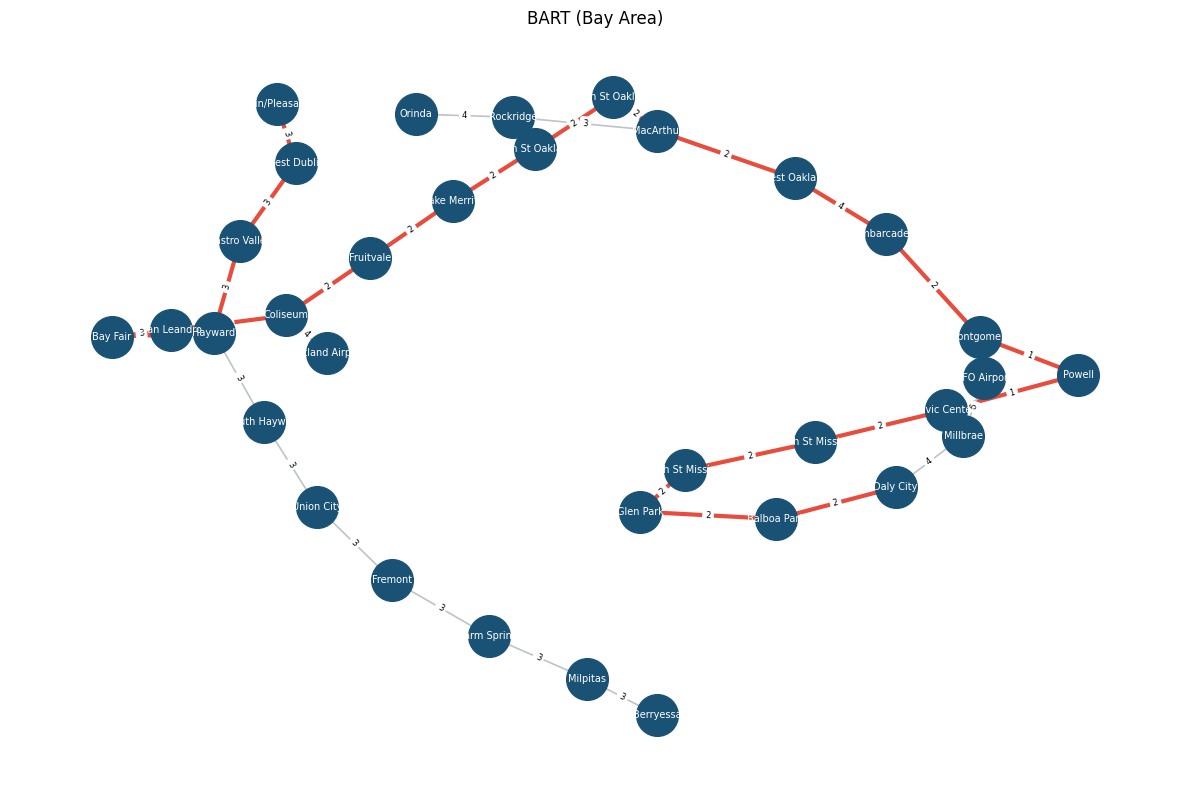

In [44]:
plot_matplotlib_rede("bart", caminho_destaque=caminho_bart)

- Bloco do relatório:

In [45]:
relatorio_bart(horario_atual)


=== BART (Bay Area) ===
Ramo leste verde, ramo norte amarelo, tronco SF e ramos SFO/Millbrae.
Menor caminho Dublin/Pleasanton → Daly City: Dublin/Pleasanton → West Dublin → Castro Valley → Hayward → Bay Fair → San Leandro → Coliseum → Fruitvale → Lake Merritt → 12th St Oakland → 19th St Oakland → MacArthur → West Oakland → Embarcadero → Montgomery → Powell → Civic Center → 16th St Mission → 24th St Mission → Glen Park → Balboa Park → Daly City
Estações com bifurcação (grau ≥ 3): Coliseum, Hayward, MacArthur, Montgomery
Custo memoizado: 98.80


# Execução de sao_paulo

- Bloco do folium:

In [46]:
caminho_sp = nx.shortest_path(
    grafo_networkx(REDES["sao_paulo"]["grafo"]),
    REDES["sao_paulo"]["origem_demo"],
    REDES["sao_paulo"]["destino_demo"],
    weight="weight",
)

mapa_sp = mapa_folium_rede("sao_paulo", caminho_sp)
display(mapa_sp)

- Chamando a função do matplotlib:

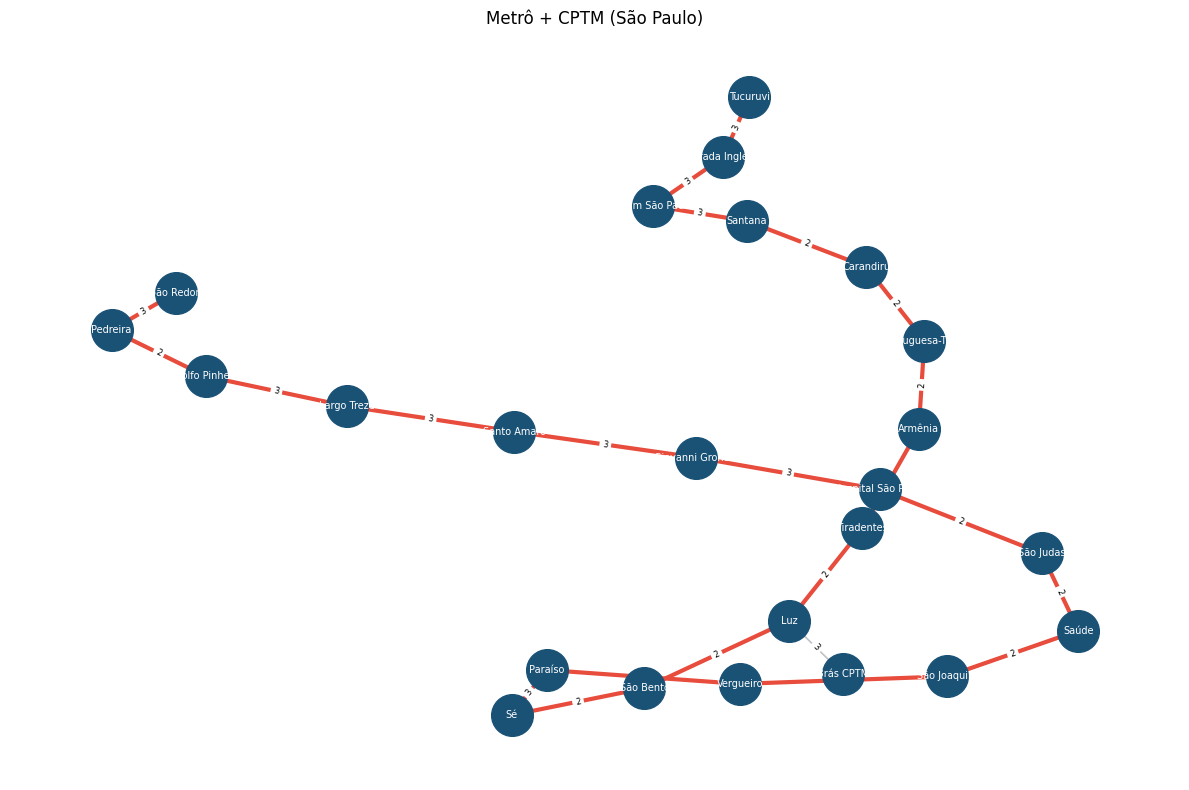

In [47]:
plot_matplotlib_rede("sao_paulo", caminho_destaque=caminho_sp)

- Bloco do relatório:

In [48]:
relatorio_sao_paulo(horario_atual)


=== Metrô + CPTM (São Paulo) ===
Integração Luz (CPTM) e Hospital São Paulo (L1/L5).
Menor caminho Tucuruvi → Capão Redondo: Tucuruvi → Parada Inglesa → Jardim São Paulo → Santana → Carandiru → Portuguesa-Tietê → Armênia → Tiradentes → Luz → São Bento → Sé → Paraíso → Vergueiro → São Joaquim → Saúde → São Judas → Hospital São Paulo → Giovanni Gronchi → Santo Amaro → Largo Treze → Adolfo Pinheiro → Pedreira → Capão Redondo
Estações de integração no percurso: Luz, Hospital São Paulo
Custo memoizado: 112.00


# Tabela de análise de desempenho

A comparação mostra que:

- A versão sem memoização recalcula diversos caminhos repetidamente, aumentando significativamente o tempo de execução.
- A versão com memoização reutiliza resultados já calculados, reduzindo drasticamente o tempo.
- O uso de memória aumenta levemente com memoização, pois os resultados são armazenados em cache.

In [49]:
def medir_rede(rede, horario):
    origem = REDES[rede]["origem_demo"]
    destino = REDES[rede]["destino_demo"]

    # SEM CACHE
    limpar_cache_menor_custo()
    tracemalloc.start()

    t0 = time.perf_counter()
    menor_custo(rede, origem, destino, horario, frozenset())
    t1 = time.perf_counter()

    mem_sem = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    # COM CACHE
    tracemalloc.start()

    t2 = time.perf_counter()
    menor_custo(rede, origem, destino, horario, frozenset())
    t3 = time.perf_counter()

    mem_com = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    return {
        "Rede": rede,
        "Origem": origem,
        "Destino": destino,
        "Tempo sem cache (s)": t1 - t0,
        "Tempo com cache (s)": t3 - t2,
        "Memória sem cache (KB)": mem_sem[1] / 1024,
        "Memória com cache (KB)": mem_com[1] / 1024,
    }

dados = []

dados = []

for rede in ["pequim", "bart", "sao_paulo"]:
    dados.append(medir_rede(rede, horario_atual))

df = pd.DataFrame(dados)
df

,Rede,Origem,Destino,Tempo sem cache (s),Tempo com cache (s),Memória sem cache (KB),Memória com cache (KB)
0,pequim,Sihui East,Xizhimen,0.000982,0.000006,52.390625,0.210938
1,bart,Dublin/Pleasanton,Daly City,0.000426,0.000005,23.609375,0.210938
2,sao_paulo,Tucuruvi,Capão Redondo,0.000347,0.000005,18.289062,0.210938


# Conclusões sobre memoização

- Reduz drasticamente o tempo de execução: Ao armazenar resultados já calculados, a função evita recomputações desnecessárias, tornando o algoritmo muito mais rápido.

- Não altera o resultado final: A memoização apenas otimiza o desempenho (o custo calculado continua exatamente o mesmo com ou sem cache).

- Impacto maior em problemas recursivos: Como a função menor_custo chama a si mesma várias vezes, o ganho com memoização é significativo.

- Transforma um algoritmo inviável em viável: Sem memoização, o tempo de execução cresce muito rápido. Com cache, o problema se torna executável em tempo aceitável.

- Troca tempo por memória: O uso de cache aumenta o consumo de memória, pois os resultados ficam armazenados, mas em compensação reduz o tempo de processamento.

- Depende de parâmetros iguais: A memoização só funciona quando a função é chamada com os mesmos parâmetros. Mudanças (como horário ou origem) geram novos cálculos.